Zadanie Należy przeprowadzić analizę regresji dla poniższych danych: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset Stwórzmy model regresji dla zmiennej zależnej density w zależności od po-
zostałych zmiennych (o watościach ciągłych)

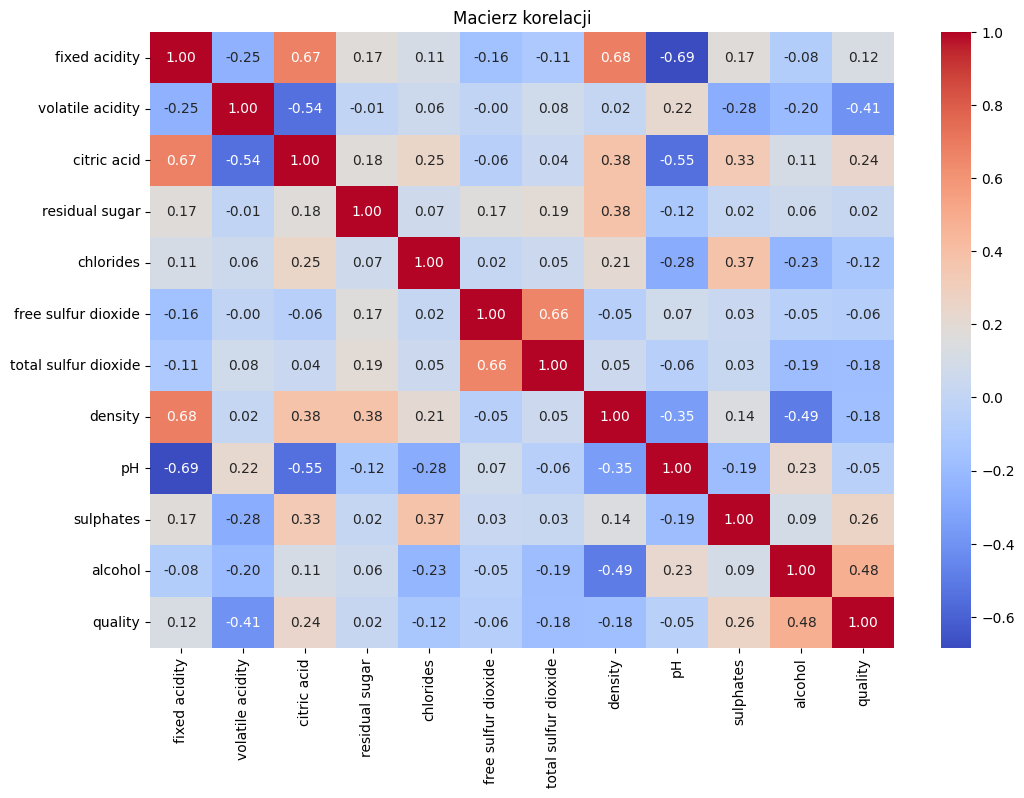

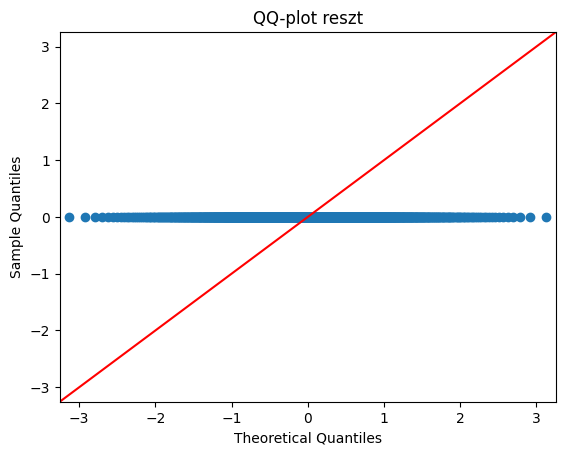

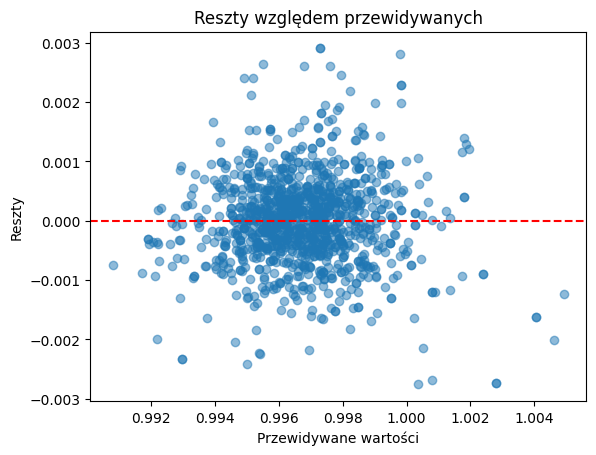

                 Zmienne         VIF
0          fixed acidity   41.538155
1       volatile acidity   18.005106
2            citric acid    9.199698
3         residual sugar    5.010441
4              chlorides    6.193151
5    free sulfur dioxide    6.274017
6   total sulfur dioxide    5.913029
7                     pH  167.922773
8              sulphates   22.323484
9                alcohol  148.296866
10               quality   77.646726


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                density   R-squared:                       0.848
 Model:                            OLS   Adj. R-squared:                  0.847
 Method:                 Least Squares   F-statistic:                     575.6
 Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
 Time:                        17:39:50   Log-Likelihood:                 6603.9
 No. Observations:                1143   AIC:                        -1.318e+04
 Df Residuals:                    1131   BIC:                        -1.312e+04
 Df Model:                          11                                         
 Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
 -----------------------------------------------------------

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

wine_data = pd.read_csv("WineQT.csv")

wine_data = wine_data.drop(columns=['Id'])

correlation_matrix = wine_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

predictors = wine_data.drop(columns=['density'])
target_variable = wine_data['density']

predictors_with_const = sm.add_constant(predictors)

ols_model = sm.OLS(target_variable, predictors_with_const).fit()

regression_summary = ols_model.summary()

predicted_values = ols_model.fittedvalues
model_residuals = ols_model.resid

shapiro_result = shapiro(model_residuals)

sm.qqplot(model_residuals, line='45')
plt.title("QQ-plot reszt")
plt.show()

plt.scatter(predicted_values, model_residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Przewidywane wartości")
plt.ylabel("Reszty")
plt.title("Reszty względem przewidywanych")
plt.show()

breusch_pagan_result = het_breuschpagan(model_residuals, predictors_with_const)

ljung_box_result = acorr_ljungbox(model_residuals, lags=[1, 2, 3], return_df=True)

vif_df = pd.DataFrame()
vif_df["Zmienne"] = predictors.columns
vif_df["VIF"] = [variance_inflation_factor(predictors.values, i) for i in range(predictors.shape[1])]

print(vif_df)

regression_summary, shapiro_result, breusch_pagan_result, ljung_box_result
